# 02 · Exploratory Data Analysis – STATS19 2023

Reads the interim merged file produced by `01-load-merge.py` and generates  
one histogram per feature (coloured by severity class) plus a class-distribution chart.

**Run after:** `01-load-merge.py`  
**Outputs:** `outputs/figures/fig-hist-<feature>-2023-v1.png`, `fig-severity-distribution-2023-v1.png`

In [7]:
# --- Paths ---
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from dotenv import load_dotenv

# Ensure `src/` is importable when running this notebook
current = Path.cwd().resolve()
for candidate in [current, *current.parents]:
    if (candidate / "data" / "interim").exists():
        REPO_ROOT = candidate
        break
else:
    REPO_ROOT = current

sys.path.insert(0, str(REPO_ROOT / "src"))
from utils.dbrepo import DBRepoClient, DBRepoError

INTERIM     = REPO_ROOT / "data" / "interim"
OUTPUTS_FIG = REPO_ROOT / "outputs" / "figures"
OUTPUTS_FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
load_dotenv()
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: C:\Users\Maxime Philippon\git\dast-2026-crash-severity-prediction


In [8]:
# --- Load the merged interim file produced from DBRepo data ---
interim_file = INTERIM / "stats19-collision-vehicle-casualty-2023-interim-v1.csv"
if interim_file.exists():
    df = pd.read_csv(interim_file)
    print(f"Loaded {len(df):,} rows from {interim_file.relative_to(REPO_ROOT)}")
else:
    client = DBRepoClient()
    try:
        df = client.get_table("t_ml_features")
        if df.empty:
            raise DBRepoError("t_ml_features exists but is empty")
        print(f"Loaded {len(df):,} rows from DBRepo table 't_ml_features'")
    except DBRepoError:
        view_candidates = ["v_ml_features", "v_ml_merged", "ml_features", "v_features"]
        view = client.find_first_existing_view(view_candidates)
        if not view:
            raise DBRepoError(f"No interim CSV or DBRepo source found among candidates: {view_candidates}")
        df = client.get_view(view)
        print(f"Loaded {len(df):,} rows from view '{view}'")

df.head(3)

Loaded 132,977 rows from data\interim\stats19-collision-vehicle-casualty-2023-interim-v1.csv


,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,casualty_distance_banding,road_type,speed_limit,weather_conditions,light_conditions,road_surface_conditions,time,day_of_week,number_of_vehicles,vehicle_type
0,2023201345434,2023,201345434,1,1,3,1,72,10,3,...,-1,6,30,2,1,2,20:08,7,1,9
1,2023522400767,2023,522400767,2,1,1,1,18,4,3,...,-1,6,20,9,1,1,10:38,3,2,1
2,2023010425559,2023,010425559,1,1,1,1,21,5,3,...,-1,6,20,1,4,1,00:30,1,3,3


In [9]:
# --- Map numeric severity codes to readable labels ---
# STATS19 codes: 1 = Fatal, 2 = Serious, 3 = Slight
SEVERITY_MAP     = {1: "Fatal", 2: "Serious", 3: "Slight"}
SEVERITY_PALETTE = {"Slight": "#4C9BE8", "Serious": "#F4A261", "Fatal": "#E76F51"}

df["severity_label"] = df["casualty_severity"].map(SEVERITY_MAP)

print("Class distribution:")
print(df["severity_label"].value_counts())

Class distribution:
severity_label
Slight     105323
Serious     26030
Fatal        1624
Name: count, dtype: int64


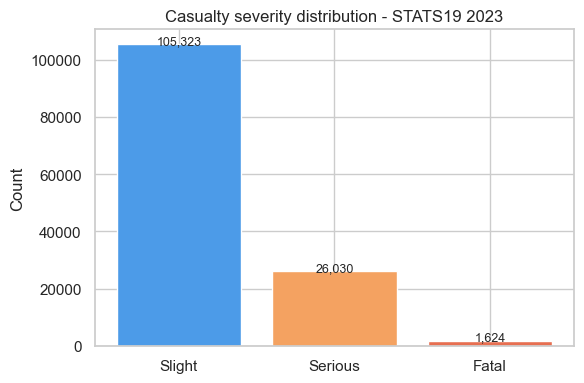

In [10]:
# --- Bar chart showing how many casualties per severity class ---
counts = df["severity_label"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values,
       color=[SEVERITY_PALETTE[s] for s in counts.index])
ax.set_title("Casualty severity distribution - STATS19 2023")
ax.set_ylabel("Count")
for i, (lbl, val) in enumerate(zip(counts.index, counts.values)):
    ax.text(i, val + 200, f"{val:,}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUTS_FIG / "fig-severity-distribution-2023-v1.png", dpi=150)
plt.show()

In [11]:
# --- One histogram per feature, coloured by severity class ---
FEATURE_COLS = [
    "road_type", "speed_limit", "weather_conditions", "light_conditions",
    "road_surface_conditions", "day_of_week", "number_of_vehicles", "vehicle_type",
]
existing = [c for c in FEATURE_COLS if c in df.columns]

for feat in existing:
    fig, ax = plt.subplots(figsize=(9, 4))

    if df[feat].nunique() <= 20:
        # Few unique values -> grouped bar chart
        plot_df = (
            df.groupby([feat, "severity_label"])
            .size()
            .reset_index(name="count")
        )
        sns.barplot(data=plot_df, x=feat, y="count", hue="severity_label",
                    palette=SEVERITY_PALETTE, ax=ax)
        ax.tick_params(axis="x", rotation=45)
    else:
        # Many unique values -> overlapping histogram
        for sev, grp in df.groupby("severity_label"):
            ax.hist(grp[feat].dropna(), bins=30, alpha=0.6,
                    label=sev, color=SEVERITY_PALETTE.get(sev, "grey"))
        ax.legend()

    ax.set_title(f"{feat} by severity")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(OUTPUTS_FIG / f"fig-hist-{feat}-2023-v1.png", dpi=150)
    plt.close(fig)
    print(f"Saved: fig-hist-{feat}-2023-v1.png")

Saved: fig-hist-road_type-2023-v1.png
Saved: fig-hist-speed_limit-2023-v1.png
Saved: fig-hist-weather_conditions-2023-v1.png
Saved: fig-hist-light_conditions-2023-v1.png
Saved: fig-hist-road_surface_conditions-2023-v1.png
Saved: fig-hist-day_of_week-2023-v1.png
Saved: fig-hist-number_of_vehicles-2023-v1.png
Saved: fig-hist-vehicle_type-2023-v1.png


In [12]:
# --- Quick overview of missing values for all feature columns ---
null_summary = df[existing + ["casualty_severity"]].isnull().sum().rename("null_count").to_frame()
null_summary["pct"] = (null_summary["null_count"] / len(df) * 100).round(2)
print(null_summary)

                         null_count  pct
road_type                         0  0.0
speed_limit                       0  0.0
weather_conditions                0  0.0
light_conditions                  0  0.0
road_surface_conditions           0  0.0
day_of_week                       0  0.0
number_of_vehicles                0  0.0
vehicle_type                      0  0.0
casualty_severity                 0  0.0
